<a href="https://colab.research.google.com/github/Leyangw/Leyangw.github.io/blob/master/Copy_of_drifting_model_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Drifting Models: A Step-by-Step Demo

**Paper:** Generative Modeling via Drifting

This demo walks you through the core algorithm with hands-on examples:

1. **Part 1: Core Algorithm** — The drifting loss and drift computation
2. **Part 2: Toy 2D** — Visualize dynamics on swiss roll & checkerboard

**More samples and full results can be found in the paper.**

---

# Install packages

In [ ]:
!pip install -q matplotlib numpy torch torchvision tqdm einops

In [ ]:
import os
import sys
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Device selection
# - In Colab: prefer CUDA (GPU) and warn if GPU isn't enabled
# - Locally: prefer CUDA, then Apple Silicon MPS, then CPU
IN_COLAB = (
    "google.colab" in sys.modules
    or os.environ.get("COLAB_GPU") is not None
    or os.environ.get("COLAB_TPU_ADDR") is not None
)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif (not IN_COLAB) and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE} (IN_COLAB={IN_COLAB})")
if IN_COLAB and DEVICE.type != "cuda":
    print(
        "[Warning] Colab is not running with GPU enabled. Please select 'Runtime -> Change runtime type -> GPU' in the menu and re-run this cell."
    )

Using device: cpu (IN_COLAB=True)
[Warning] Colab is not running with GPU enabled. Please select 'Runtime -> Change runtime type -> GPU' in the menu and re-run this cell.


# Part 1: Core Algorithm

**Traditional generative models** (Diffusion, Flow Matching) iterate at **inference time**.

**Drifting Models** move the iteration to **training time**:
- Each training step "drifts" the generated samples according to a drifting field
- At inference: just one forward pass (1 NFE)

## Training Objective

Given a generator $f_\theta$ that maps noise $\epsilon$ to samples, the training loss is:

$$
L = \mathbb{E}_{\epsilon} \Big[ \big\| f_\theta(\epsilon) - \text{stopgrad}\big(f_\theta(\epsilon) + \mathbf{V}_{p,q}(f_\theta(\epsilon))\big) \big\|^2 \Big]
$$

We move predictions toward their **drifted** versions. The drifting field $\mathbf{V}_{p,q}$, depending on the data distribution $p$ and the generated distribution $q$, tells each generated sample where to go. This can be implemented as the following code.

In [ ]:

def drifting_loss(gen: torch.Tensor, pos: torch.Tensor, compute_drift):
    """Drifting loss: MSE(gen, stopgrad(gen + V))."""
    with torch.no_grad():
        V = compute_drift(gen, pos)
        target = (gen + V).detach()
    return F.mse_loss(gen, target)

## Mean-shift Drifting Field

Having described the general training objective, we now describe a concrete instantiation of the drifting field $\mathbf{V}_{p,q}$.

In principle, $\mathbf{V}_{p,q}$ can be a wide range of vector fields, as long as it satisfies $\mathbf{V}_{p,p} = \mathbf{0}$. In this paper, we use an instantiation inspired by **mean-shift**, defined as

$$
\mathbf{V}_{p,q}(\mathbf{x}) := \mathbf{V}_p^{+}(\mathbf{x}) - \mathbf{V}_q^{-}(\mathbf{x}),
$$

where

$$
\mathbf{V}_p^{+}(\mathbf{x}) := \frac{1}{Z_p(\mathbf{x})} \, \mathbb{E}_{\mathbf{y}^{+} \sim p} \big[ k(\mathbf{x}, \mathbf{y}^{+}) (\mathbf{y}^{+} - \mathbf{x}) \big], \quad \mathbf{V}_q^{-}(\mathbf{x}) := \frac{1}{Z_q(\mathbf{x})} \, \mathbb{E}_{\mathbf{y}^{-} \sim q} \big[ k(\mathbf{x}, \mathbf{y}^{-}) (\mathbf{y}^{-} - \mathbf{x}) \big].
$$

The normalizers are

$$
Z_p(\mathbf{x}) := \mathbb{E}_{\mathbf{y}^{+} \sim p} \big[ k(\mathbf{x}, \mathbf{y}^{+}) \big], \quad Z_q(\mathbf{x}) := \mathbb{E}_{\mathbf{y}^{-} \sim q} \big[ k(\mathbf{x}, \mathbf{y}^{-}) \big].
$$

Substituting into $\mathbf{V}_{p,q} = \mathbf{V}_p^{+} - \mathbf{V}_q^{-}$, we obtain the compact form

$$
\mathbf{V}_{p,q}(\mathbf{x}) = \frac{1}{Z_p(\mathbf{x}) Z_q(\mathbf{x})} \, \mathbb{E}_{\mathbf{y}^{+} \sim p, \, \mathbf{y}^{-} \sim q} \big[ k(\mathbf{x}, \mathbf{y}^{+}) \, k(\mathbf{x}, \mathbf{y}^{-}) \, (\mathbf{y}^{+} - \mathbf{y}^{-}) \big].
$$

---

### Implementation (batch-normalized Monte Carlo estimate)

In practice, we approximate the above expectation using mini-batches. Specifically, we use

$$
\mathbf{V}(\mathbf{x}) := \mathbb{E} \big[ K_B(\mathbf{x}, \mathbf{y}^{+}) \, K_B(\mathbf{x}, \mathbf{y}^{-}) \, (\mathbf{y}^{+} - \mathbf{y}^{-}) \big],
$$

where $K_B$ is a **batch-normalized kernel**: the kernel $k$ is normalized over samples in batch $B$.

This construction guarantees $\mathbf{V}_{p,p} = \mathbf{0}$: when $p = q$, the term $(\mathbf{y}^{+} - \mathbf{y}^{-})$ is anti-symmetric and cancels out in expectation. The resulting field can be efficiently estimated via Monte Carlo over mini-batches.

Below is a reference PyTorch-style implementation, where $k(\mathbf{x}, \mathbf{y}) = \exp(-\|\mathbf{x} - \mathbf{y}\| / \tau)$, and $K_B$ implements the normalization across both $\mathbf x$ and $\mathbf y$, since we found it to slightly improve performance.

In [ ]:
# ============================================================
# Core: Compute Drift V and Loss (from toy_mean_drift.py)
# ============================================================

def compute_drift(
    gen: torch.Tensor,
    pos: torch.Tensor,
    temp: float = None,
    bandwidths=(2.0**-2, 2.0**-1, 2.0**0, 2.0**1, 2.0**2),
    weights=None,
):
    """
    Compute drift field using a mixture of Laplace kernels:

        k_h(x, y) = exp(-||x-y|| / h)

    with bandwidths h in {2^-2, 2^-1, 2^0, 2^1, 2^2}.

    Args:
        gen: Generated samples [G, D]
        pos: Data samples [P, D]
        temp: kept only for compatibility with train_toy; not used if bandwidths is given
        bandwidths: list/tuple of kernel bandwidths
        weights: optional mixture weights, same length as bandwidths

    Returns:
        V: Drift vectors [G, D]
    """
    targets = torch.cat([gen, pos], dim=0)
    G = gen.shape[0]

    # Pairwise distance: [G, G + P]
    dist = torch.cdist(gen, targets)

    # Mask self-interaction among generated samples
    self_mask = torch.eye(G, device=gen.device, dtype=torch.bool)
    dist = dist.clone()
    dist[:, :G] = dist[:, :G].masked_fill(self_mask, 1e6)

    if weights is None:
        weights = torch.ones(len(bandwidths), device=gen.device) / len(bandwidths)
    else:
        weights = torch.as_tensor(weights, device=gen.device, dtype=gen.dtype)
        weights = weights / weights.sum()

    V_mix = 0.0

    for w, h in zip(weights, bandwidths):
        h = torch.as_tensor(h, device=gen.device, dtype=gen.dtype)

        # Laplace kernel with bandwidth h
        kernel = torch.exp(-dist / h)

        # Your original two-sided normalization
        row_sum = kernel.sum(dim=-1, keepdim=True)      # [G, 1]
        col_sum = kernel.sum(dim=-2, keepdim=True)      # [1, G + P]

        normalizer = row_sum * col_sum
        normalizer = normalizer.clamp_min(1e-12).sqrt()

        normalized_kernel = kernel / normalizer

        # Positive attraction from data samples
        pos_mass = normalized_kernel[:, :G].sum(dim=-1, keepdim=True)
        pos_coeff = normalized_kernel[:, G:] * pos_mass
        pos_V = pos_coeff @ targets[G:]

        # Negative repulsion from generated samples
        neg_mass = normalized_kernel[:, G:].sum(dim=-1, keepdim=True)
        neg_coeff = normalized_kernel[:, :G] * neg_mass
        neg_V = neg_coeff @ targets[:G]

        V_h = pos_V - neg_V
        V_mix = V_mix + w * V_h

    return V_mix




## Visualize the Drifting Field

Let's see what the drifting field look like for a randomly initialized $q$.

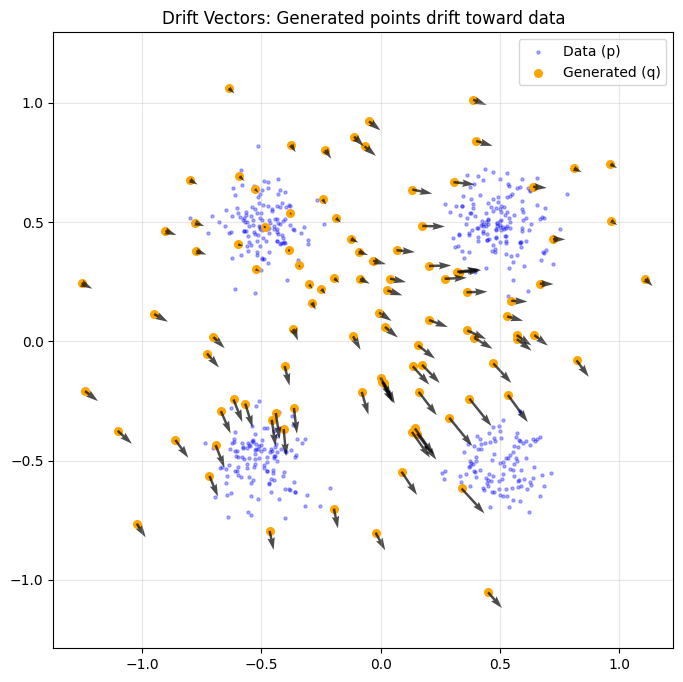

In [ ]:
# Quick visualization of drift vectors
torch.manual_seed(42)

# Random generated points (from Gaussian)
gen_test = torch.randn(100, 2) * 0.5

# Target data: simple 4-mode Gaussian mixture
centers = torch.tensor([[-0.5, -0.5], [-0.5, 0.5], [0.5, -0.5], [0.5, 0.5]])
idx = torch.randint(0, 4, (500,))
pos_test = centers[idx] + torch.randn(500, 2) * 0.1

# Compute drift
drift_test = compute_drift(gen_test, pos_test, temp=0.2)

# Plot
plt.figure(figsize=(8, 8))
plt.scatter(pos_test[:, 0], pos_test[:, 1], s=5, alpha=0.3, c='blue', label='Data (p)')
plt.scatter(gen_test[:, 0], gen_test[:, 1], s=30, c='orange', label='Generated (q)')
plt.quiver(gen_test[:, 0], gen_test[:, 1], drift_test[:, 0], drift_test[:, 1],
           scale=3, color='black', alpha=0.7, width=0.004)
plt.legend()
plt.title('Drift Vectors: Generated points drift toward data')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

---

# Part 2: Toy 2D Examples

Let's train on 2D distributions to visualize the full training dynamics.

We'll use two classic test distributions:
- **Checkerboard**: 4 diagonally-arranged squares (tests mode coverage)
- **Swiss Roll**: Spiral pattern (tests learning complex geometry)

In [ ]:
import torch
import numpy as np

from torch.distributions import (
    Categorical,
    Independent,
    MixtureSameFamily,
    Normal,
)

from matplotlib import pyplot as plt

import itertools


def MoG5(scale=3.0, std=0.2 ,device="cpu", dim=2):
    mean = torch.tensor([[-scale, -scale]*(dim//2), [-scale, scale]*(dim//2), [scale, -scale]*(dim//2), [-scale, 0.0]*(dim//2), [0.0, -scale]*(dim//2)], device=device)
    comp = Independent(Normal(mean, torch.ones(5,dim, device=device)*std), 1)
    mix = Categorical(torch.tensor([1, 1, 1, 1, 1.], device=device))
    return MixtureSameFamily(mix, comp)

def MoG9(scale=3.0, std=0.2 ,device="cpu", dim=2):
    mean = torch.tensor([[-scale, -scale]*(dim//2), [-scale, scale]*(dim//2), [scale, -scale]*(dim//2), [scale, scale]*(dim//2), [-scale, 0.0]*(dim//2), [scale, 0.0]*(dim//2), [0.0, -scale]*(dim//2), [0.0, scale]*(dim//2), [0.0, 0.0]*(dim//2)], device=device)
    comp = Independent(Normal(mean, torch.ones(9,dim, device=device)*std), 1)
    mix = Categorical(torch.tensor([1, 1, 1, 1, 1, 1, 1, 1, 1], device=device))
    return MixtureSameFamily(mix, comp)

def is_scalar(x):
    if isinstance(x, torch.Tensor):
        return x.dim() == 0 or (x.dim() == 1 and x.size(0) == 1)
    else:
        return isinstance(x, (int, float))

def BatchMoG9(scale=3.0,std=0.2,device="cpu"):
    if is_scalar(scale) and is_scalar(std):
        """scale and std are in the shape of [1] or are scalars
        """
        return MoG9(scale, std)
    else:
        """scale and std are in the shape of [B, 1]
        """
        B = scale.size(0)

        mix = Categorical(torch.tensor([1.0/9.0]*9,device=device).expand(B,9))
        mask = torch.tensor([[-1, -1], [-1, 1], [1, 1], [1, -1], [-1, 0.0], [1, 0.0], [0.0, -1], [0.0, 1], [0.0, 0.0]],device=device)
        mean = mask.unsqueeze(0) * scale.reshape(B,1,1)
        std = torch.ones(B,9,2,device=device)*std.reshape(B,1,1)
        comp = Independent(Normal(mean, std), 1)
    return MixtureSameFamily(mix, comp)

def get_BatchMoG9_true_score(x_t, alpha_t, sigma_t, gamm_scale=3.0, gmm_std=0.2):

    noisy_gmm=BatchMoG9(scale=gamm_scale*alpha_t,std=torch.sqrt(alpha_t**2*gmm_std**2+sigma_t**2),device=x_t.device)
    noisy_log_densities=noisy_gmm.log_prob(x_t.requires_grad_(True))
    return torch.autograd.grad(noisy_log_densities.sum(), x_t, create_graph=False)[0]


def plot_MoG9(samples, save_path, save_name=None):
    plt.figure(figsize=(10, 10))
    plt.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.6)
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.savefig(f"""{save_path}/{save_name}.png""")
    plt.close()

def MoG4(scale=1.0,std=0.2, weights=[0.25, 0.25, 0.25, 0.25]):
    mean = torch.tensor([[-scale, -scale,], [-scale, scale], [scale, scale], [scale, -scale]])
    comp = Independent(Normal(mean, torch.ones(4,2)*std), 1)
    mix = Categorical(torch.tensor(weights))
    return MixtureSameFamily(mix, comp)

class GMM(torch.nn.Module):
    def __init__(self, dim, n_mixes, loc_scaling, log_var_scaling=0.1, seed=0,
                 n_test_set_samples=1000, device="cpu", spread_std=0.0):
        super(GMM, self).__init__()
        torch.manual_seed(0)
        self.seed = seed
        torch.manual_seed(seed)
        self.n_mixes = n_mixes
        self.dim = dim
        self.n_test_set_samples = n_test_set_samples

        mean = (torch.rand((n_mixes, dim)) - 0.5)*2 * loc_scaling
        std = torch.sqrt(torch.nn.functional.softplus(torch.ones((n_mixes, dim)) * log_var_scaling)+spread_std**2)

        self.register_buffer("cat_probs", torch.ones(n_mixes))
        self.register_buffer("locs", mean)
        self.register_buffer("scale_trils", torch.diag_embed(std))
        self.device = device
        self.to(self.device)

    def to(self, device):
        if device == "cuda":
            if torch.cuda.is_available():
                self.cuda()
        else:
            self.cpu()

    @property
    def distribution(self):
        mix = torch.distributions.Categorical(self.cat_probs.to(self.device))
        com = torch.distributions.MultivariateNormal(self.locs.to(self.device),
                                                     scale_tril=self.scale_trils.to(self.device),
                                                     validate_args=False)
        return torch.distributions.MixtureSameFamily(mixture_distribution=mix,
                                                     component_distribution=com,
                                                     validate_args=False)

    @property
    def test_set(self) -> torch.Tensor:
        return self.sample((self.n_test_set_samples, ))

    def log_prob(self, x: torch.Tensor):
        log_prob = self.distribution.log_prob(x)
        mask = torch.zeros_like(log_prob)
        mask[log_prob < -1e4] = - torch.tensor(float("inf"))
        log_prob = log_prob + mask
        return log_prob

    def sample(self, shape=(1,)):
        return self.distribution.sample(shape)


def plot_contours(log_prob_func,
                  samples = None,
                  ax = None,
                  bounds = (-5.0, 5.0),
                  grid_width_n_points = 20,
                  n_contour_levels = None,
                  log_prob_min = -1000.0,
                  device='cpu',
                  plot_marginal_dims=[0, 1],
                  s=2,
                  alpha=0.6,
                  title=None,
                  plt_show=True,
                  xy_tick=True,):
    """Plot contours of a log_prob_func that is defined on 2D"""
    if ax is None:
        fig, ax = plt.subplots(1)
    x_points_dim1 = torch.linspace(bounds[0], bounds[1], grid_width_n_points)
    x_points_dim2 = x_points_dim1
    x_points = torch.tensor(list(itertools.product(x_points_dim1, x_points_dim2)), device=device)
    log_p_x = log_prob_func(x_points).cpu().detach()
    log_p_x = torch.clamp_min(log_p_x, log_prob_min)
    log_p_x = log_p_x.reshape((grid_width_n_points, grid_width_n_points))
    x_points_dim1 = x_points[:, 0].reshape((grid_width_n_points, grid_width_n_points)).cpu().numpy()
    x_points_dim2 = x_points[:, 1].reshape((grid_width_n_points, grid_width_n_points)).cpu().numpy()
    if n_contour_levels:
        ax.contour(x_points_dim1, x_points_dim2, log_p_x, levels=n_contour_levels)
    else:
        ax.contour(x_points_dim1, x_points_dim2, log_p_x)

    if samples is not None:
        samples = np.clip(samples, bounds[0], bounds[1])
        ax.scatter(samples[:, plot_marginal_dims[0]], samples[:, plot_marginal_dims[1]], s=s, alpha=alpha)
        ### x,y ticks
        if xy_tick:
            ax.set_xticks([-40,0,40])
            ax.set_yticks([-40,0,40])
        ### size of ticks
        ax.tick_params(axis='both', which='major', labelsize=15)
    if title:
        ax.set_title(title)
        ### size of title
        ax.title.set_fontsize(40)
    if plt_show:
        plt.show()

def setup_quadratic_function(x: torch.Tensor, seed: int = 0):
    # Useful for porting this problem to non torch libraries.
    torch.random.manual_seed(seed)
    # example function that we may want to calculate expectations over
    x_shift = 2 * torch.randn(x.shape[-1])
    A = 2 * torch.rand((x.shape[-1], x.shape[-1])).to(x.device)
    b = torch.rand(x.shape[-1]).to(x.device)
    torch.seed()  # set back to random number
    if x.dtype == torch.float64:
        return x_shift.double(), A.double(), b.double()
    else:
        assert x.dtype == torch.float32
        return x_shift, A, b


def quadratic_function(x: torch.Tensor, seed: int = 0):
    x_shift, A, b = setup_quadratic_function(x, seed)
    x = x + x_shift
    return torch.einsum("bi,ij,bj->b", x, A, x) + torch.einsum("i,bi->b", b, x)


def MC_estimate_true_expectation(samples, expectation_function):
    f_samples = expectation_function(samples)
    return torch.mean(f_samples)

def relative_mae(true_expectation, est_expectation):
    return torch.abs((est_expectation - true_expectation) / true_expectation)

def BatchKDE(emp_data, mean_scale, std, device="cpu"):
    """
    Batch version for the KDE model.
    """
    data_size=emp_data.size(0)
    B = mean_scale.size(0)  # Batch size

    # Create mixture distribution
    mix = Categorical(torch.tensor([1.0/data_size]*data_size, device=device).expand(B, data_size))

    mean = emp_data.unsqueeze(0) * mean_scale.reshape(B, 1, 1)  # Scale the means per batch

    # Standard deviations
    std = torch.ones(B, data_size, 2, device=device) * std.reshape(B, 1, 1)

    # Create multivariate normal components
    comp = torch.distributions.MultivariateNormal(mean, scale_tril=torch.diag_embed(std))
    # Return the mixture model
    return MixtureSameFamily(mix, comp)

def get_KDE_true_score(emp_data,x_t, alpha_t, sigma_t):
    """
    Compute true score function for the GMM40 model.
    """
    # Generate noisy GMM with 40 components using BatchGMM40
    noisy_gmm = BatchKDE(emp_data,mean_scale=alpha_t, std=sigma_t, device=x_t.device)
    # Get log densities
    noisy_log_densities = noisy_gmm.log_prob(x_t.requires_grad_(True))

    # Compute gradients
    return torch.autograd.grad(noisy_log_densities.sum(), x_t, create_graph=False)[0]

MOG40_COMPONENT_MEANS = torch.tensor(
    [
        [-0.2995, 21.4577],
        [-32.9218, -29.4376],
        [-15.4062, 10.7263],
        [-0.7925, 31.7156],
        [-3.5498, 10.5845],
        [-12.0885, -7.8626],
        [-38.2139, -26.4913],
        [-16.4889, 1.4817],
        [15.8134, 24.0009],
        [-27.1176, -17.4185],
        [14.5287, 33.2155],
        [-8.2320, 29.9325],
        [-6.4473, 4.2326],
        [36.2190, -37.1068],
        [-25.1815, -10.1266],
        [-15.5920, 34.5600],
        [-25.9272, -18.4133],
        [-27.9456, -37.4624],
        [-23.3496, 34.3839],
        [17.8487, 19.3869],
        [2.1037, -20.5073],
        [6.7674, -37.3478],
        [-28.9026, -20.6212],
        [25.2375, 23.4529],
        [-17.7398, -1.4433],
        [25.5824, 39.7653],
        [15.8753, 5.4037],
        [26.8195, -23.5521],
        [7.4538, -31.0122],
        [-27.7234, -20.6633],
        [18.0989, 16.0864],
        [-23.6941, 12.0843],
        [21.9589, -5.0487],
        [1.5273, 9.2682],
        [24.8151, 38.4078],
        [-30.8249, -14.6588],
        [15.7204, 33.1420],
        [34.8083, 35.2943],
        [7.9606, -34.7833],
        [3.6797, -25.0242],
    ],
    dtype=torch.float32,
)


def MoG40(mean_scale=1.0, std=None, device="cpu"):
    """
    Scalar 40-component GMM in 2D.

    Uses the fixed component means from BatchGMM40 without a batch dimension.
    """
    if std is None:
        std = torch.nn.functional.softplus(torch.tensor(1.0, device=device))

    mean_scale_t = torch.as_tensor(mean_scale, device=device, dtype=torch.float32)
    std_t = torch.as_tensor(std, device=device, dtype=torch.float32)

    mix = Categorical(torch.ones(40, device=device) / 40.0)
    mean = MOG40_COMPONENT_MEANS.to(device) * mean_scale_t
    scale_tril = torch.diag_embed(torch.ones(40, 2, device=device) * std_t)
    comp = torch.distributions.MultivariateNormal(mean, scale_tril=scale_tril)
    return MixtureSameFamily(mix, comp)


def BatchGMM40(mean_scale, std, device="cpu"):
    """
    Batch version for a GMM with 40 mixtures.
    Scale and std can either be scalars or batch-shaped [B, 1]
    """
    B = mean_scale.size(0)  # Batch size

    # Create mixture distribution
    mix = Categorical(torch.tensor([1.0/40.0]*40, device=device).expand(B, 40))

    mean = MOG40_COMPONENT_MEANS.to(device).unsqueeze(0) * mean_scale.reshape(B, 1, 1)

    # Standard deviations
    std = torch.ones(B, 40, 2, device=device) * std.reshape(B, 1, 1)

    # Create multivariate normal components
    comp = torch.distributions.MultivariateNormal(mean, scale_tril=torch.diag_embed(std))
    # Return the mixture model
    return MixtureSameFamily(mix, comp)


def get_BatchGMM40_true_score(x_t, alpha_t, sigma_t):
    mean_scale=torch.tensor(1.0,device=x_t.device)
    gmm_std=torch.nn.functional.softplus(torch.tensor(1.0,device=x_t.device))
    """
    Compute true score function for the GMM40 model.
    """
    # Generate noisy GMM with 40 components using BatchGMM40
    noisy_gmm = BatchGMM40(mean_scale=alpha_t, std=torch.sqrt((alpha_t*gmm_std)**2 + sigma_t**2), device=x_t.device)
    # Get log densities
    noisy_log_densities = noisy_gmm.log_prob(x_t.requires_grad_(True))

    # Compute gradients
    return torch.autograd.grad(noisy_log_densities.sum(), x_t, create_graph=False)[0]

def mode_eval(log_prob_function,samples):
    with torch.no_grad():
        return log_prob_function(samples.detach()).mean()


def plot_MoG40(log_prob_function,samples, save_path, save_name=None,title=None):
    if save_name is None:
        plot_contours(log_prob_function, samples=samples.detach().cpu().numpy(), bounds=(-56,56), n_contour_levels=50, grid_width_n_points=200, device="cpu",title=title,plt_show=True)
    else:
        plot_contours(log_prob_function, samples=samples.detach().cpu().numpy(), bounds=(-56,56), n_contour_levels=50, grid_width_n_points=200, device="cpu",title=title,plt_show=False)
        plt.savefig(f"""{save_path}/{save_name}.png""")
        plt.close()

def mode_eval(log_prob_function,samples):
    with torch.no_grad():
        return log_prob_function(samples.detach()).mean()




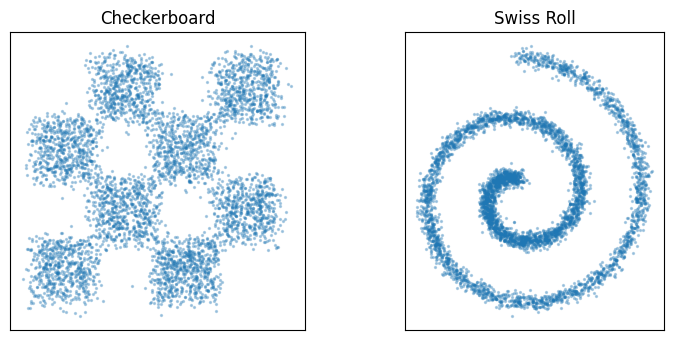

In [ ]:
# ============================================================
# Toy Dataset Samplers (minimal; copied from toy_mean_drift.py)
# ============================================================

def sample_checkerboard(n: int, noise: float = 0.05, seed: int | None = None) -> torch.Tensor:
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    b = torch.randint(0, 2, (n,), generator=g)
    i = torch.randint(0, 2, (n,), generator=g) * 2 + b
    j = torch.randint(0, 2, (n,), generator=g) * 2 + b
    u = torch.rand(n, generator=g)
    v = torch.rand(n, generator=g)
    pts = torch.stack([i + u, j + v], dim=1) - 2.0
    pts = pts / 2.0
    if noise > 0:
        pts = pts + noise * torch.randn(pts.shape, generator=g)
    return pts


def sample_swiss_roll(n: int, noise: float = 0.03, seed: int | None = None) -> torch.Tensor:
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    u = torch.rand(n, generator=g)
    t = 0.5 * math.pi + 4.0 * math.pi * u
    pts = torch.stack([t * torch.cos(t), t * torch.sin(t)], dim=1)
    pts = pts / (pts.abs().max() + 1e-8)
    if noise > 0:
        pts = pts + noise * torch.randn(pts.shape, generator=g)
    return pts


# quick look
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, (name, sampler) in zip(axes, [("Checkerboard", sample_checkerboard), ("Swiss Roll", sample_swiss_roll)]):
    pts = sampler(5000).numpy()
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.3)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Training Loop for Toy 2D
# ============================================================
from functools import partial
class MLP(nn.Module):
    """MLP: noise -> output. 3 hidden layers with SiLU."""
    def __init__(self, in_dim=32, hidden=256, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, z):
        return self.net(z)

def train_toy(sampler, steps=2000, data_batch_size=2048, gen_batch_size=2048, lr=1e-3, temp=0.05,
              in_dim=32, hidden=256, plot_every=500, seed=42):
    """Train drifting model. Returns model and loss history."""
    torch.manual_seed(seed)
    model = MLP(in_dim=in_dim, hidden=hidden, out_dim=2).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    ema = None
    pbar = tqdm(range(1, steps + 1))
    for step in pbar:
        pos = sampler(data_batch_size).to(DEVICE)
        gen = model(torch.randn(gen_batch_size, in_dim, device=DEVICE))
        loss = drifting_loss(gen, pos, compute_drift=partial(compute_drift, temp=temp))

        opt.zero_grad()
        loss.backward()
        opt.step()

        loss_history.append(loss.item())
        ema = loss.item() if ema is None else 0.96 * ema + 0.04 * loss.item()
        pbar.set_postfix(loss=f"{ema:.2e}")

        if step % plot_every == 0 or step == 1:
            with torch.no_grad():
                vis = model(torch.randn(5000, in_dim, device=DEVICE)).cpu().numpy()
                gt = sampler(5000).numpy()
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
            ax1.scatter(gt[:, 0], gt[:, 1], s=2, alpha=0.3, c='black')
            ax1.set_title('Target'); ax1.set_aspect('equal'); ax1.axis('off')
            ax2.scatter(vis[:, 0], vis[:, 1], s=2, alpha=0.3, c='tab:orange')
            ax2.set_title(f'Generated (step {step})'); ax2.set_aspect('equal'); ax2.axis('off')
            plt.tight_layout(); plt.show()

    return model, loss_history

  0%|          | 0/2000 [00:00<?, ?it/s]

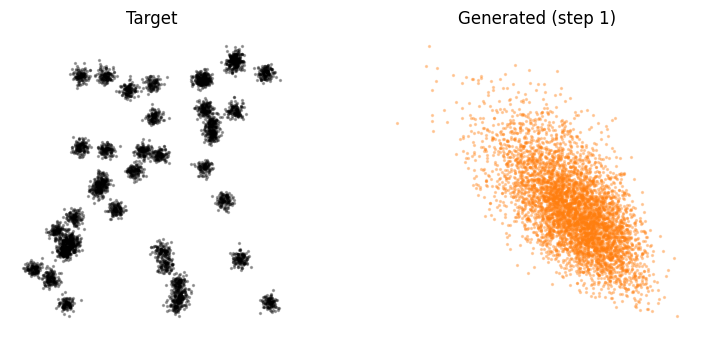

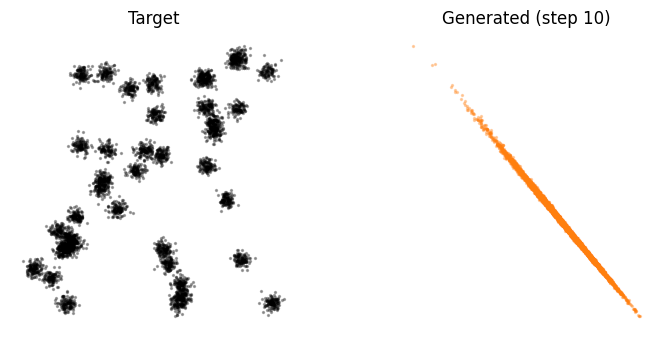

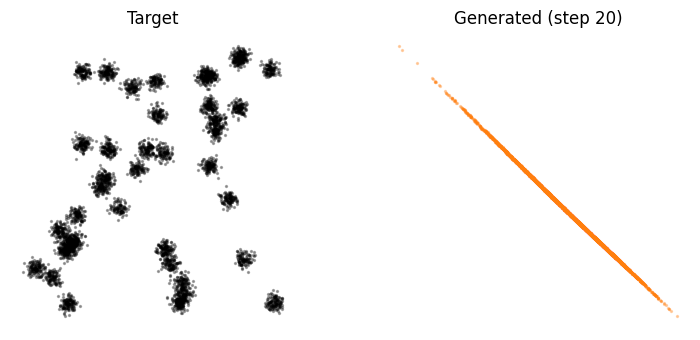

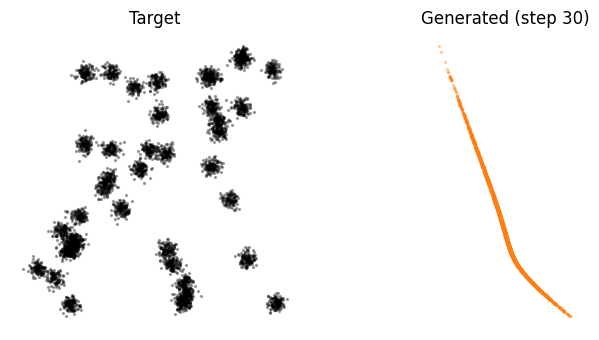

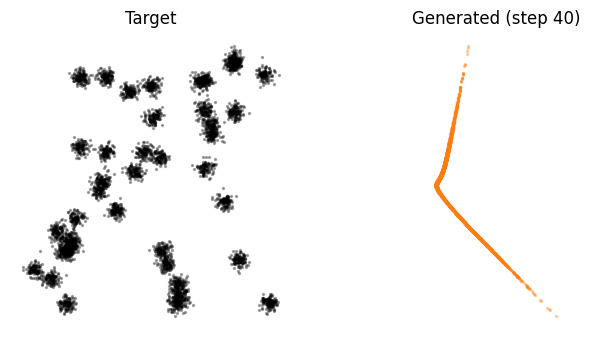

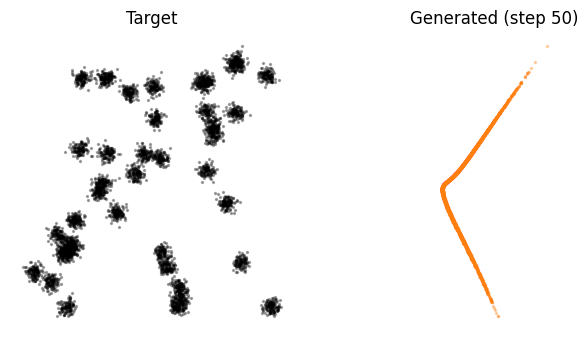

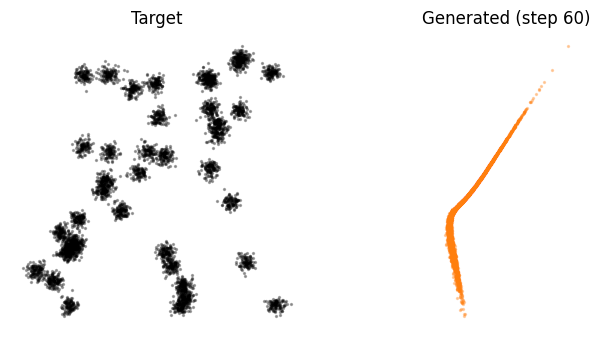

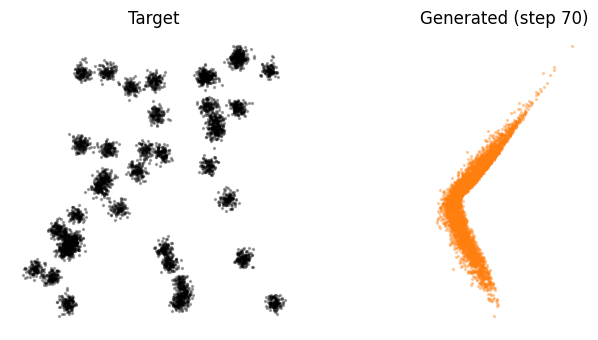

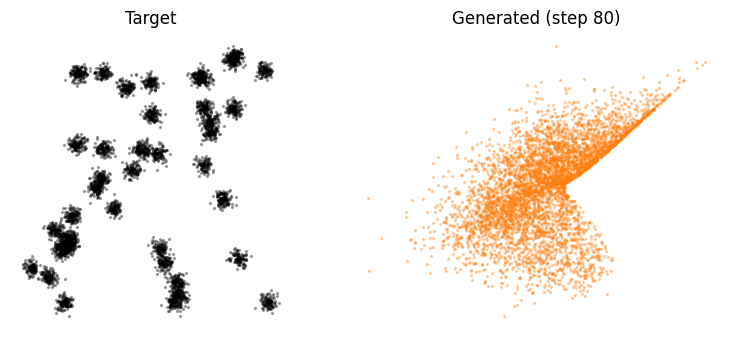

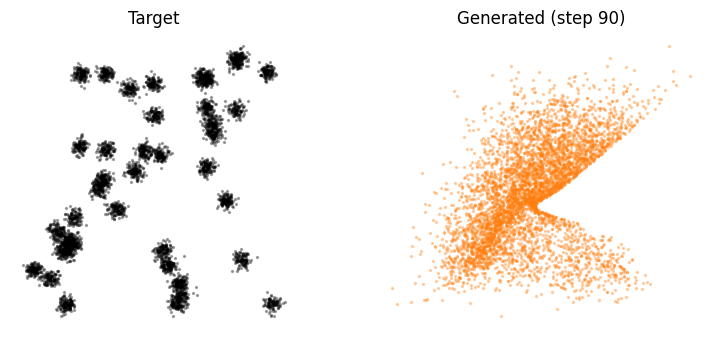

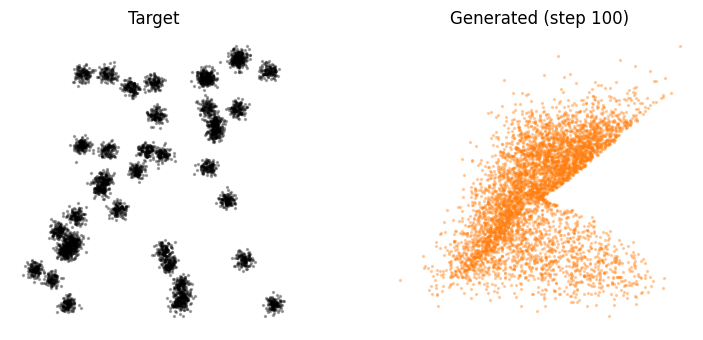

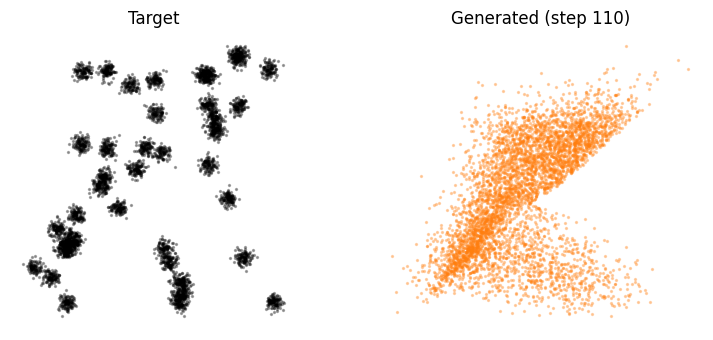

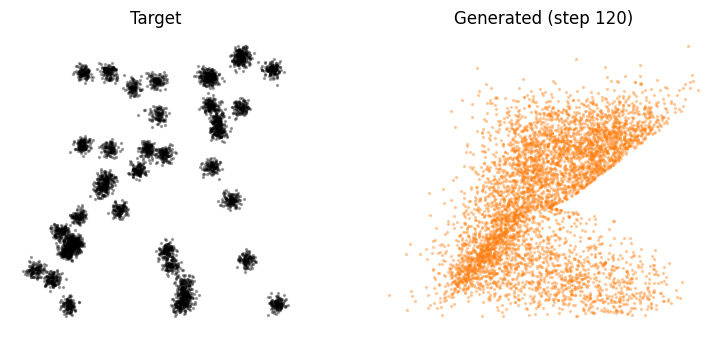

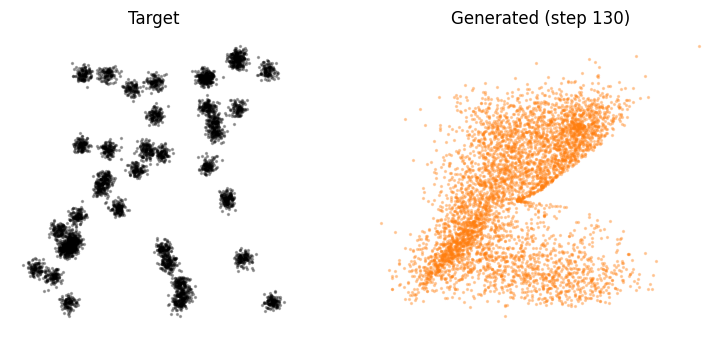

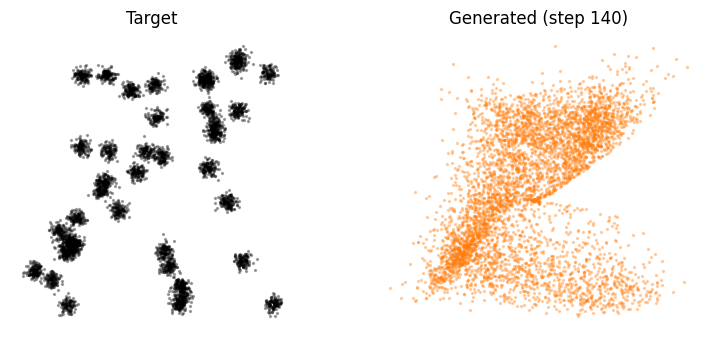

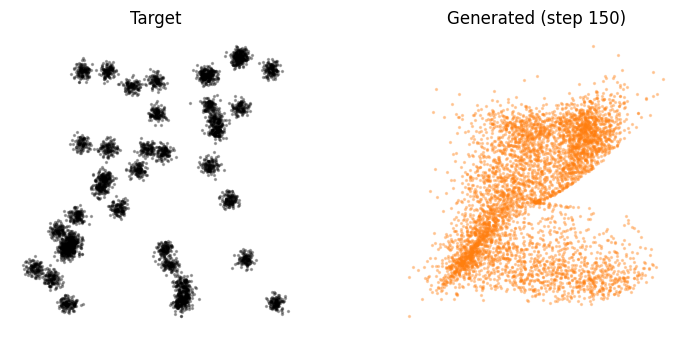

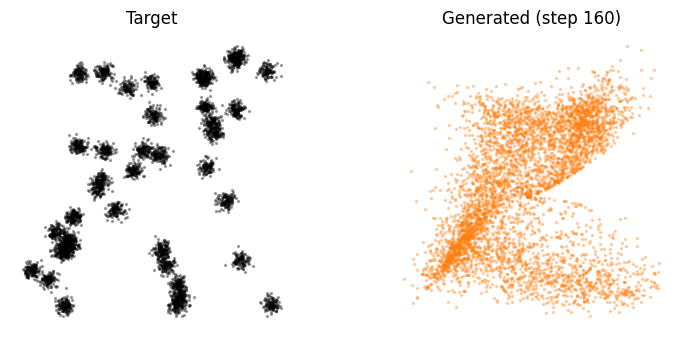

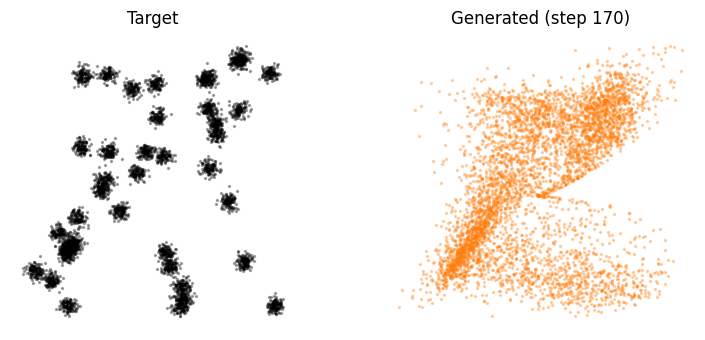

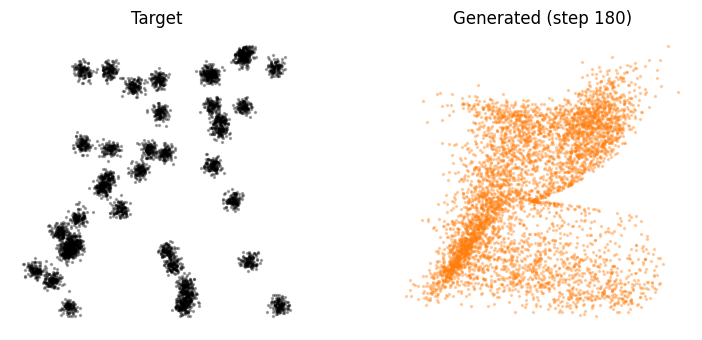

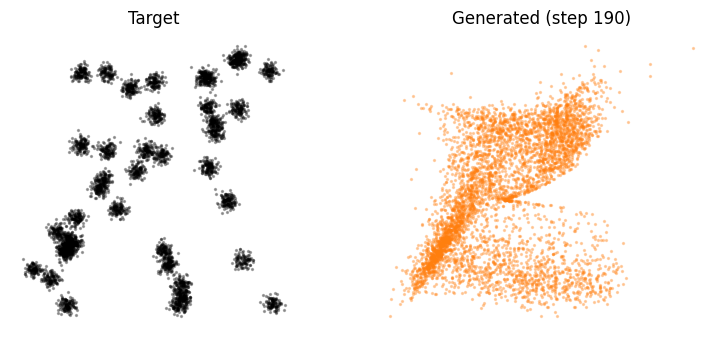

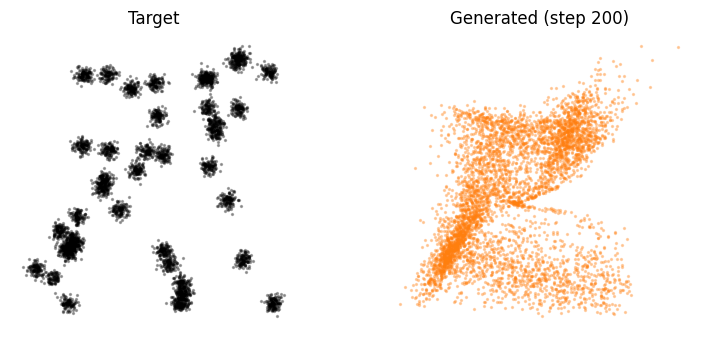

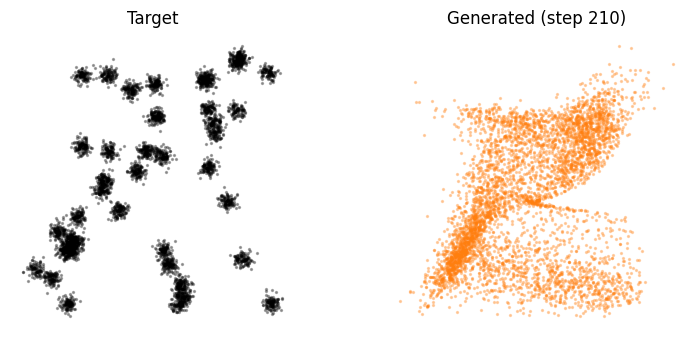

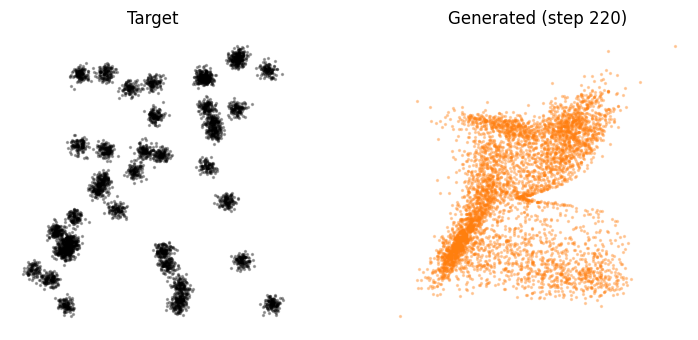

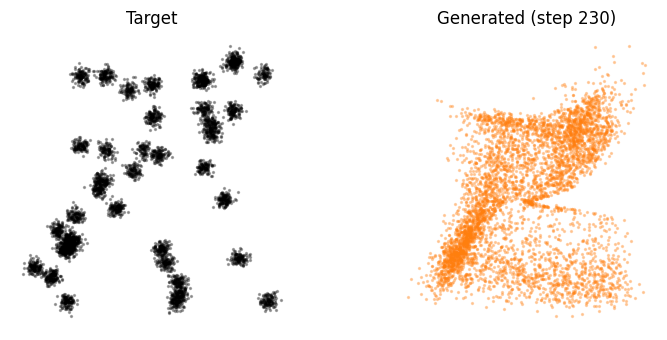

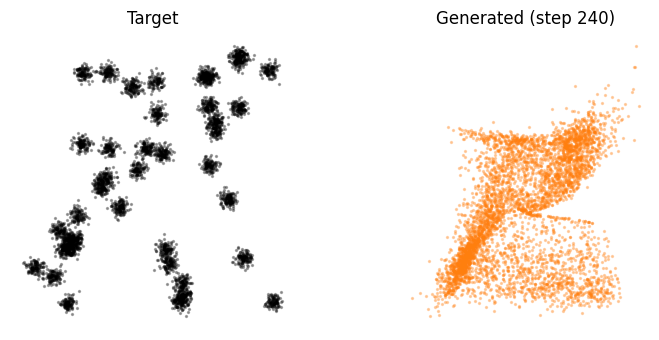

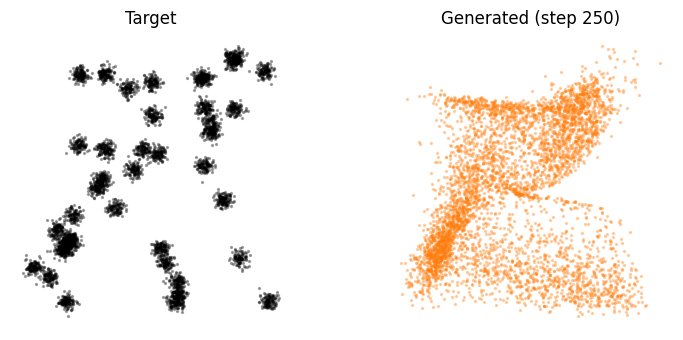

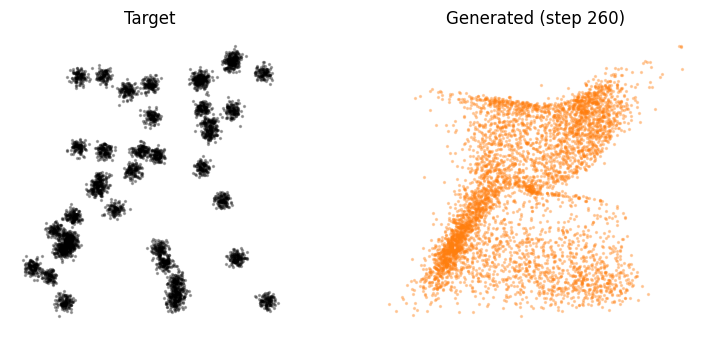

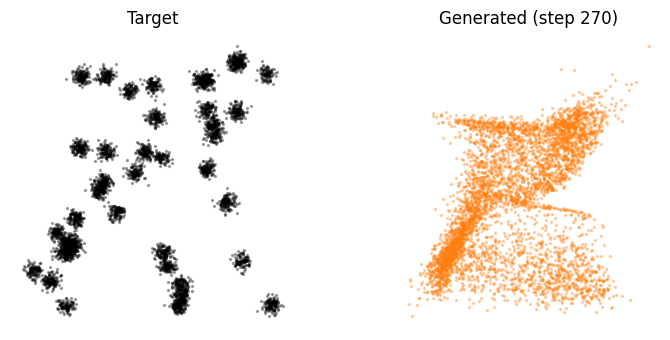

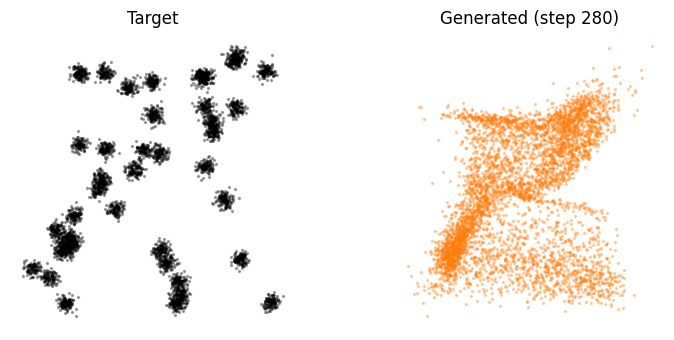

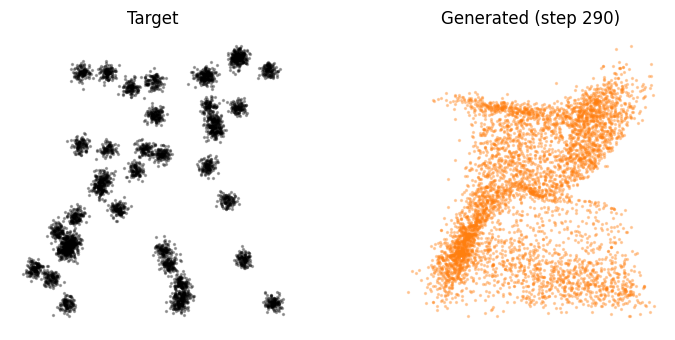

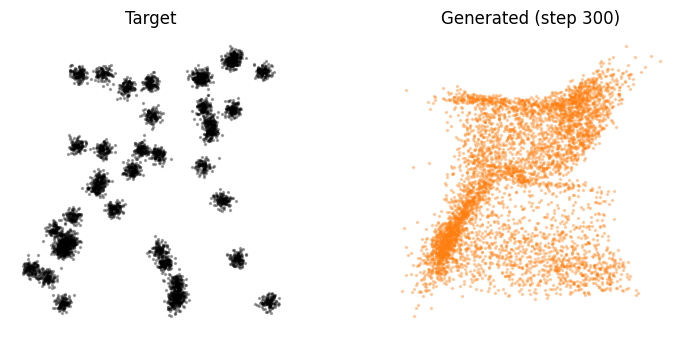

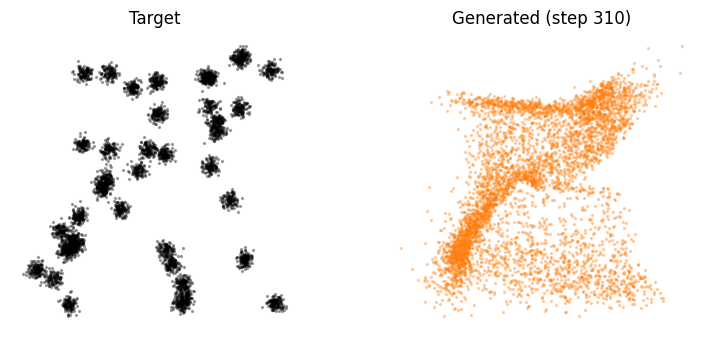

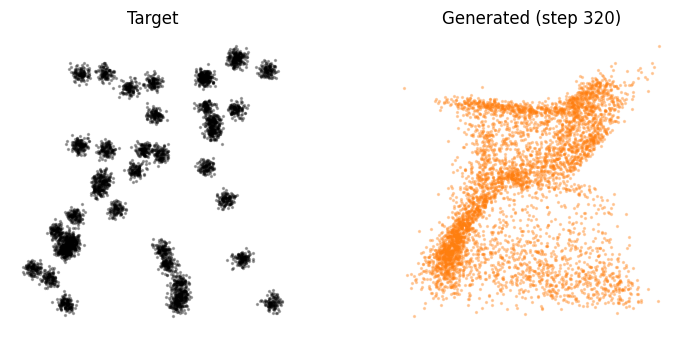

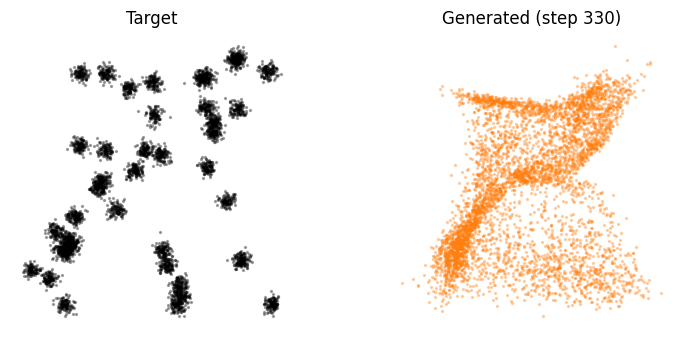

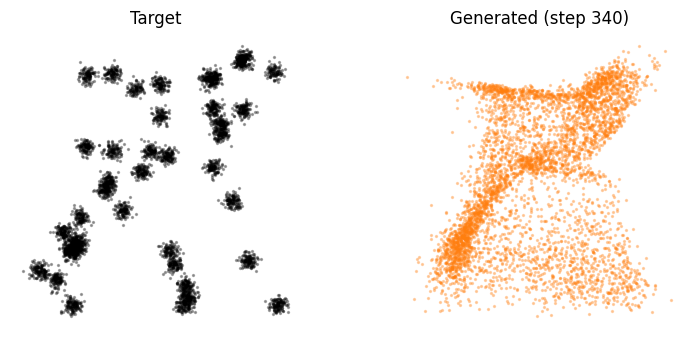

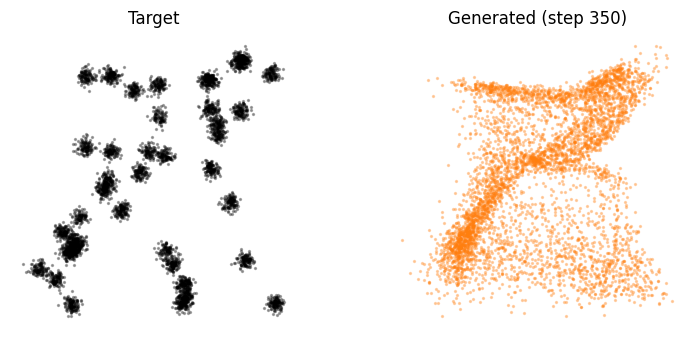

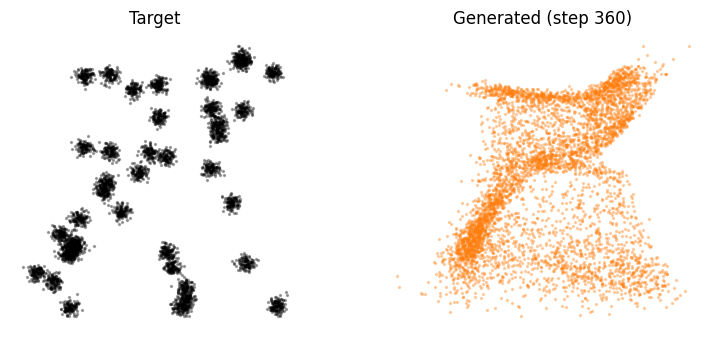

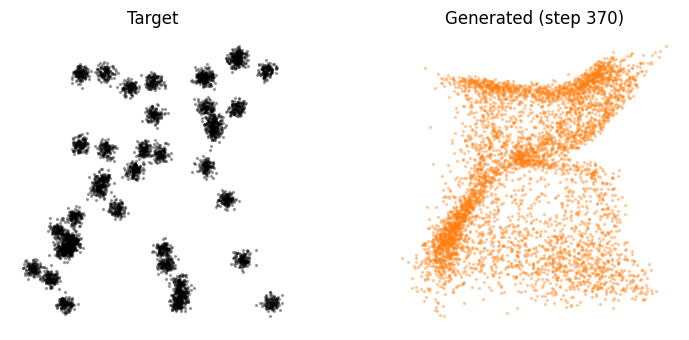

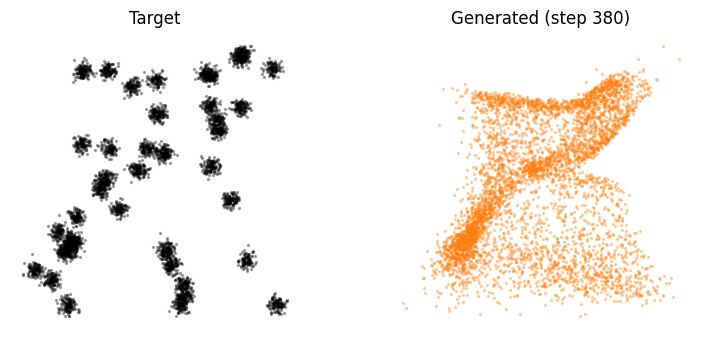

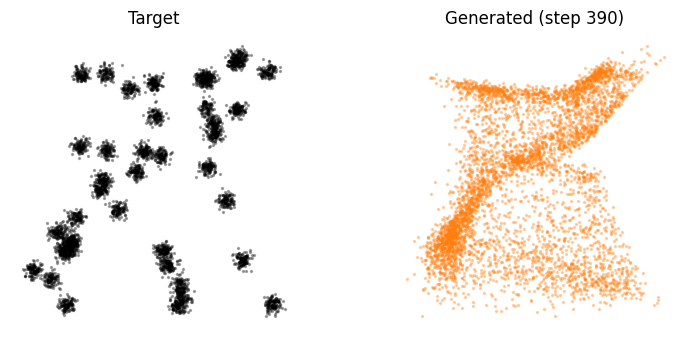

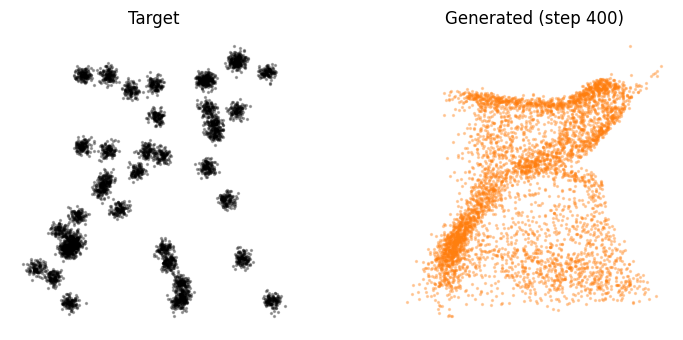

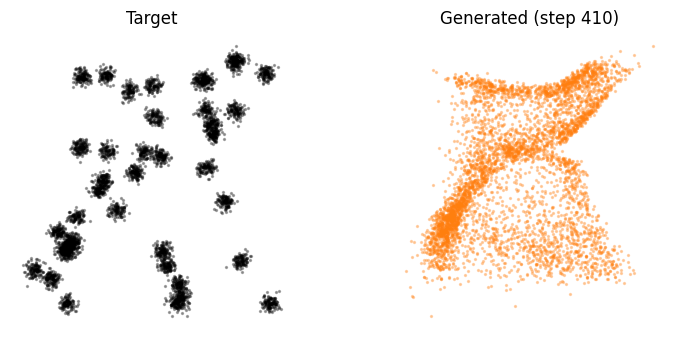

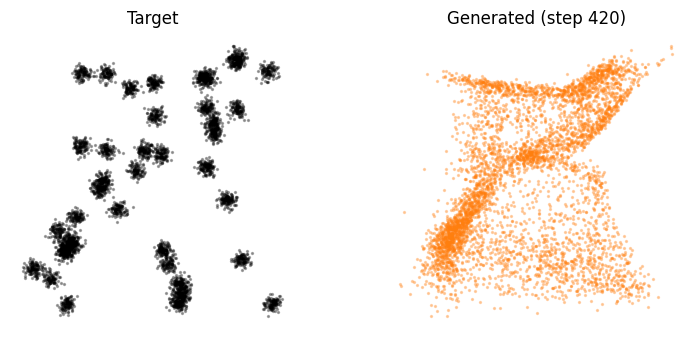

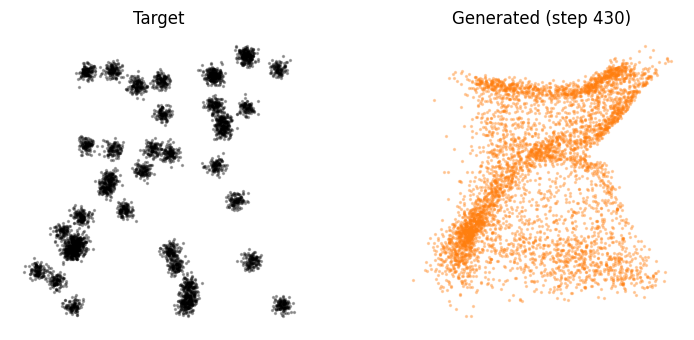

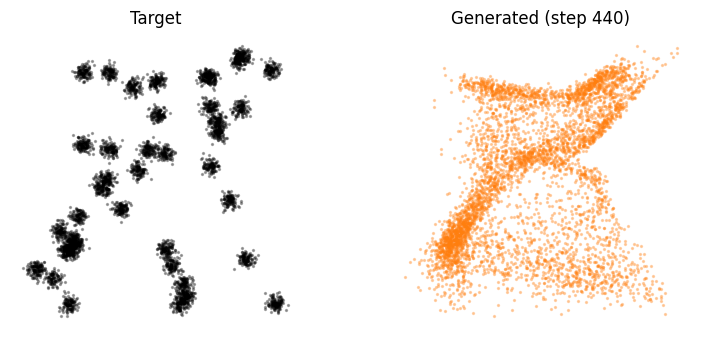

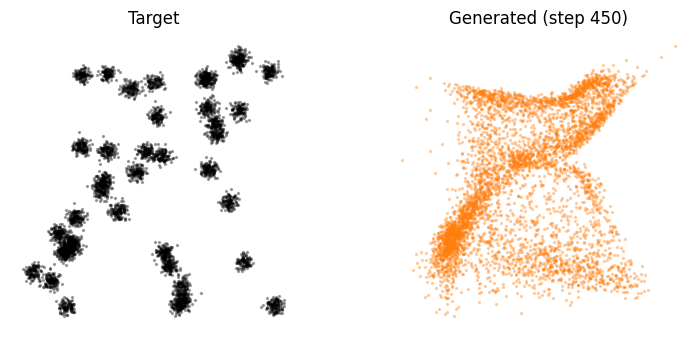

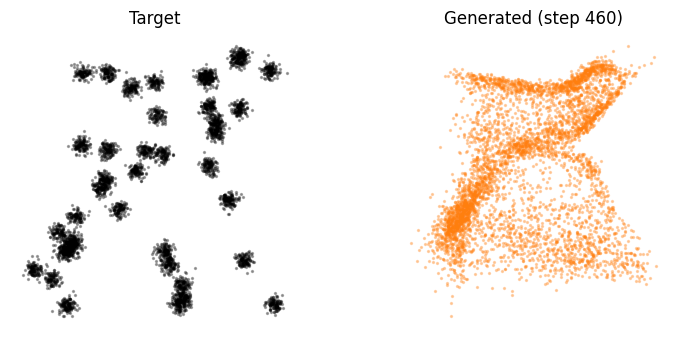

In [ ]:
# Train on Swiss Roll
def make_mog40_sampler(mean_scale=1.0, std=None):
    """
    Returns sampler(n) -> Tensor [n, 2] on CPU.
    """
    dist = MoG40(mean_scale=mean_scale, std=std, device="cpu")

    def sampler(n):
        with torch.no_grad():
            return dist.sample((n,)).float().cpu()

    return sampler

sampler = make_mog40_sampler(mean_scale=1.0)

model, loss_history = train_toy(
    sampler=sampler,
    steps=2000,
    hidden=400,
    data_batch_size=4096,
    gen_batch_size=4096,
    lr=1e-3,
    temp=0.05,
    plot_every=10
)

# model_swiss, loss_swiss = train_toy(sampler = sampler, steps=2000, lr=1e-3, temp=0.05)

plt.figure(figsize=(6, 3))
plt.plot(loss_swiss, alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Swiss Roll Loss Curve')
plt.yscale('log'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


In [ ]:

# Train on Checkerboard
print("\nTraining on Checkerboard...")
model_checker, loss_checker = train_toy(sample_checkerboard, steps=2000, lr=1e-3, temp=0.05)

plt.figure(figsize=(6, 3))
plt.plot(loss_checker, alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Checkerboard Loss Curve')
plt.yscale('log'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()